In [7]:
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained
import numpy as np
import pandas as pd
import math

In [ ]:
df = pd.read_csv("data/cluster.csv")

df.head(5)   

cords = df[["lat","lon"]].to_numpy()

In [ ]:
total_package = df.shape[0]
available_drivers = 10
max_package = math.ceil(total_package/available_drivers)
max_weight = 500 # Not devloieping this uet 

clf = KMeansConstrained(
    n_clusters=available_drivers, # centriod
    n_init=30, # randomization to find best rmse
    random_state=42,# random seed
    size_max=max_package # max package per centroid 
)

clf.fit(cords)


KMeansConstrained(copy_x=True, init='k-means++', max_iter=300, n_clusters=10,
         n_init=30, n_jobs=1, random_state=42, size_max=10, size_min=None,
         tol=0.0001, verbose=False)

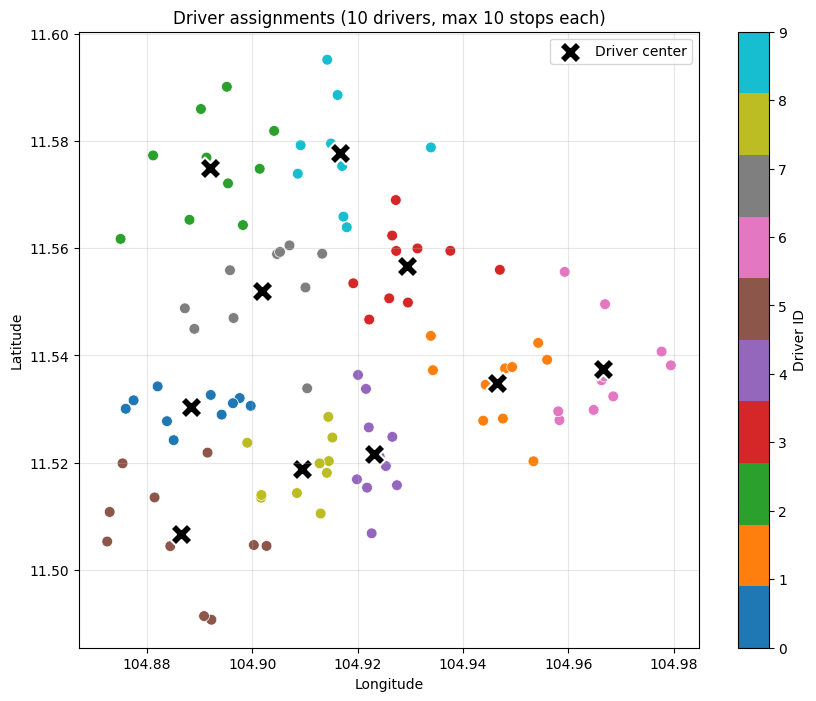

driver_id
0    10
1    10
2    10
3    10
4    10
5    10
6    10
7    10
8    10
9    10
dtype: int64


In [12]:
import matplotlib.pyplot as plt

df['driver_id'] = clf.labels_

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    df['lon'], df['lat'],
    c=df['driver_id'],
    cmap='tab10',
    s=60,
    edgecolors='white',
    linewidth=0.5
)

plt.scatter(
    clf.cluster_centers_[:, 1],   # lon is index 1
    clf.cluster_centers_[:, 0],   # lat is index 0
    c='black',
    marker='X',
    s=250,
    label='Driver center',
    edgecolors='white',
    linewidth=1.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Driver assignments ({available_drivers} drivers, max {max_package} stops each)')
plt.legend()
plt.colorbar(scatter, label='Driver ID')
plt.grid(alpha=0.3)
plt.show()

print(df.groupby('driver_id').size())